In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import load_npz

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

In [2]:
# Load TF-IDF data
X_train_tfidf = load_npz("../data/processed/X_train_tfidf.npz")
X_test_tfidf = load_npz("../data/processed/X_test_tfidf.npz")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze("columns")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze("columns")

print("Training data:", X_train_tfidf.shape)
print("Testing data:", X_test_tfidf.shape)

Training data: (35751, 10000)
Testing data: (8938, 10000)


In [3]:
# Load Word2Vec data
X_train_w2v = np.load("../data/processed/X_train_w2v.npy")
X_test_w2v = np.load("../data/processed/X_test_w2v.npy")

print("Word2Vec training data:", X_train_w2v.shape)
print("Word2Vec testing data:", X_test_w2v.shape)

Word2Vec training data: (35751, 100)
Word2Vec testing data: (8938, 100)


In [4]:
# Train Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_tfidf, y_train)

logistic_pred = logistic_model.predict(X_test_tfidf)

print("Logistic Regression evaluated.")

Logistic Regression evaluated.


In [5]:
# Train Random Forest
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

data = pd.read_csv("../data/processed/cleaned_news.csv")

data["clean_content"] = data["clean_content"].fillna("")
data["clean_content"] = data["clean_content"].astype(str)

X = data["clean_content"]
y = data["label"]

X_train_text, X_test_text, y_train_rf, y_test_rf = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

rf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    stop_words="english",
    sublinear_tf=True
)

X_train_rf = rf_vectorizer.fit_transform(X_train_text)
X_test_rf = rf_vectorizer.transform(X_test_text)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train_rf)

rf_pred = rf_model.predict(X_test_rf)

print("Random Forest evaluated.")

Random Forest evaluated.


In [6]:
# KNN
knn_vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    stop_words="english",
    sublinear_tf=True
)

X_train_knn = knn_vectorizer.fit_transform(X_train_text)
X_test_knn = knn_vectorizer.transform(X_test_text)

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1
)

knn_model.fit(X_train_knn, y_train_rf)

knn_pred = knn_model.predict(X_test_knn)

print("KNN evaluated.")

KNN evaluated.


In [7]:
# Neural Network
nn_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    solver="adam",
    max_iter=30,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

nn_model.fit(X_train_w2v, y_train)

nn_pred = nn_model.predict(X_test_w2v)

print("Neural Network evaluated.")

Neural Network evaluated.


C:\Users\rahul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


In [10]:
# Calculate all metrics
models_predictions = {
    "Logistic Regression": (y_test, logistic_pred),
    "Random Forest": (y_test_rf, rf_pred),
    "KNN": (y_test_rf, knn_pred),
    "Neural Network": (y_test, nn_pred)
}

evaluation_results = []

for model_name, (actual, predicted) in models_predictions.items():

    accuracy = accuracy_score(actual, predicted)
    precision = precision_score(actual, predicted)
    recall = recall_score(actual, predicted)
    f1 = f1_score(actual, predicted)

    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

evaluation_df = pd.DataFrame(evaluation_results)

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

evaluation_df[metrics] = evaluation_df[metrics] * 100

evaluation_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,99.440591,99.224988,99.599246,99.411765
1,Random Forest,99.820989,99.811410,99.811410,99.811410
2,KNN,60.561647,99.312242,17.020273,29.060173
3,Neural Network,98.232267,98.160377,98.114097,98.137232


In [11]:
# classification report
for model_name, (actual, predicted) in models_predictions.items():

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(
        classification_report(
            actual,
            predicted,
            target_names=["Fake", "Real"]
        )
    )

Logistic Regression
              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99      4696
        Real       0.99      1.00      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938

Random Forest
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4696
        Real       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938

KNN
              precision    recall  f1-score   support

        Fake       0.57      1.00      0.73      4696
        Real       0.99      0.17      0.29      4242

    accuracy                           0.61      8938
   macro avg       0.78      0.58      0.51      8938
weighted avg       0.77      0.61   

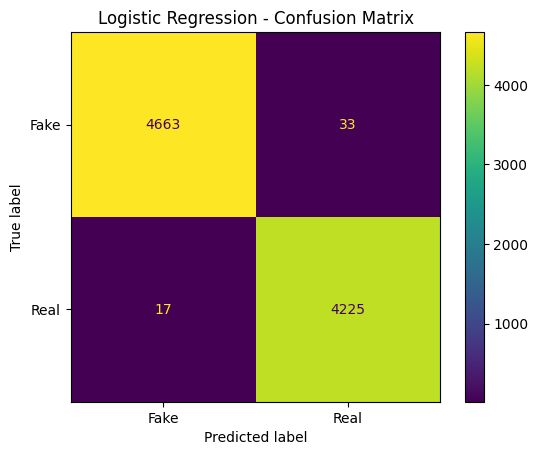

In [12]:
# Confusion Matrix: Logistic Regression
cm = confusion_matrix(y_test, logistic_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

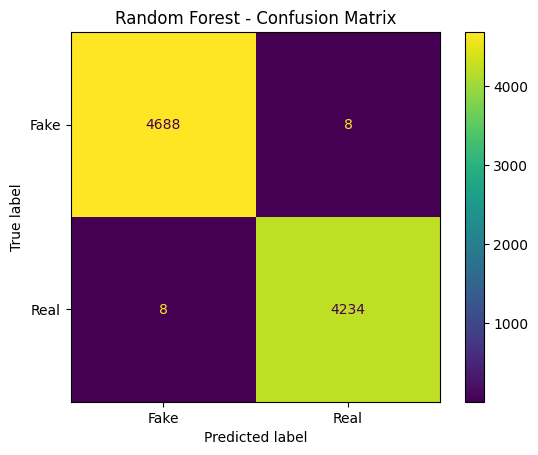

In [13]:
# Random Forest Confusion Matrix
cm = confusion_matrix(y_test_rf, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

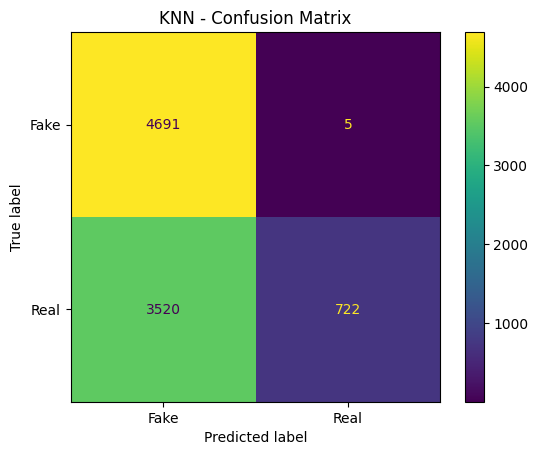

In [14]:
# KNN Confusion Matrix
cm = confusion_matrix(y_test_rf, knn_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

disp.plot()
plt.title("KNN - Confusion Matrix")
plt.show()

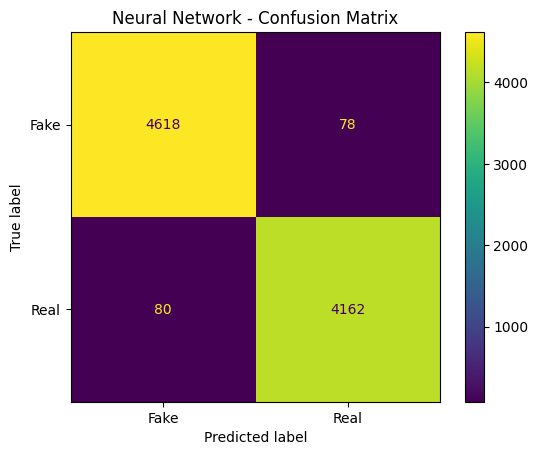

In [15]:
# Neural Network Confusion MAtrix
cm = confusion_matrix(y_test, nn_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

disp.plot()
plt.title("Neural Network - Confusion Matrix")
plt.show()

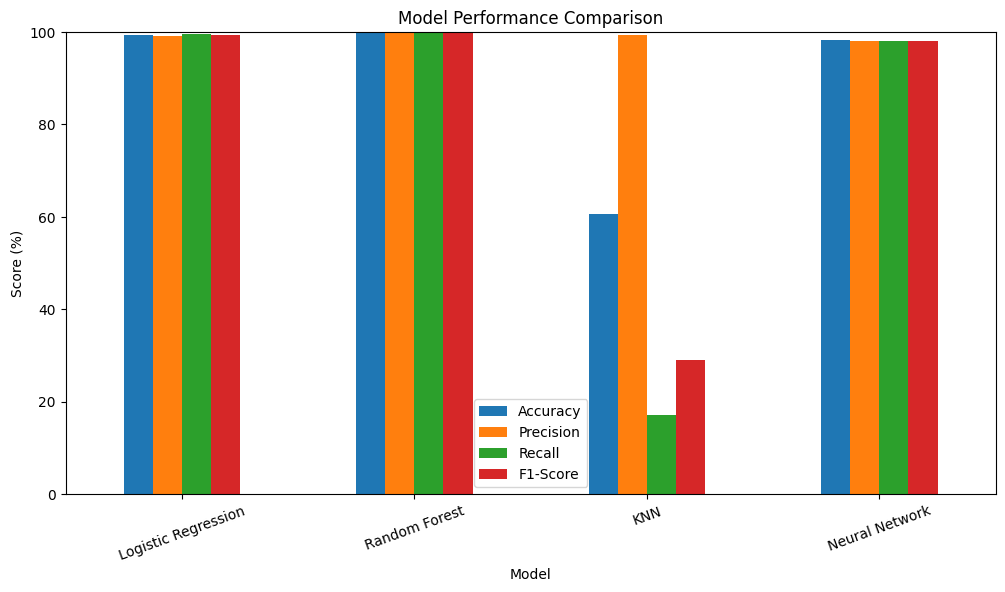

In [ ]:
# Compare all metrics visually
evaluation_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score (%)")
plt.ylim(0, 100)
plt.xticks(rotation=20)
plt.legend()
plt.show()

In [17]:
# Find the best model
best_model = evaluation_df.loc[
    evaluation_df["F1-Score"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model        Random Forest
Accuracy         99.820989
Precision         99.81141
Recall            99.81141
F1-Score          99.81141
Name: 1, dtype: object


In [ ]:
# Save evaluation results
evaluation_df.to_csv(
    "../results/evaluation_results.csv",
    index=False
)

print("Evaluation results saved successfully!")

Evaluation results saved successfully!
